# Rotten Tomatoes Sentiment Analysis

## გარემოს მომზადება

თავდაპირველად დავაიმპორტე საჭირო ბიბლიოთეკები და დავაsetupე გარემო. ასევე, მომავალში დამჭირდება პუნქტუაციები და stopwordები და მაგათაც აქ ვიწერ.

In [2]:
import kagglehub

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from collections import Counter
from tqdm import tqdm
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

nltk.download('wordnet')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

kagglehub.login()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Kaggle credentials set.
Kaggle credentials successfully validated.


## მონაცემების წაკითხვა

train და test მონაცემები წავიკითხე და ვნახე რა წერია მონაცემებში. გვაქვს ოთხი მონაცემი თითოეული entryისთვის: PhraseId, SentenceId, Phrase, Sentiment.

In [3]:
sentiment_analysis_on_movie_reviews_path = kagglehub.competition_download('sentiment-analysis-on-movie-reviews')

train_data_path = f"{sentiment_analysis_on_movie_reviews_path}/train.tsv.zip"
test_data_path = f"{sentiment_analysis_on_movie_reviews_path}/test.tsv.zip"

train_df = pd.read_csv(train_data_path, sep='\t')
test_df = pd.read_csv(test_data_path, sep='\t')

train_df.head()

100%|██████████| 1.90M/1.90M [00:01<00:00, 1.77MB/s]

Extracting files...


,PhraseId,SentenceId,Phrase,Sentiment
0,1,1,A series of escapades demonstrating the adage ...,1
1,2,1,A series of escapades demonstrating the adage ...,2
2,3,1,A series,2
3,4,1,A,2
4,5,1,series,2


## მონაცემების ანალიზი და დამუშავება

მოდელის დატრენინგებისთვის ცხადია არ გამოგავდგება PhraseId და SentenceId, რადგან ისინი არანაირ ინფორმაციას გვაძველევენ phraseის sentimentთან დაკავშირებით. აქედან გამომდინარე შემიძლია, რომ გადავაგდო. ასევე, არასრულ მონაცემებს გადავაგდებ.

In [4]:
train_df = train_df.dropna()
train_df = train_df.drop(['PhraseId', 'SentenceId'], axis=1)

sentimentების განაწილებას რომ დავაკვირდეთ ახლა. ჩანს რომ ნორმალური განაწილებაა და კარგია ეგ. დიდი ალბათობით მსგავსი შედეგს მივიღებ ბევრ მონაცემზეც, რომ ფრაზების უმეტესობა ნეიტრალურია და რადიკალური ფრაზების რაოდენობა მცირეა, რაც მომავალში შეიძლება მოდელის არჩევის დროს გამომადგეს.

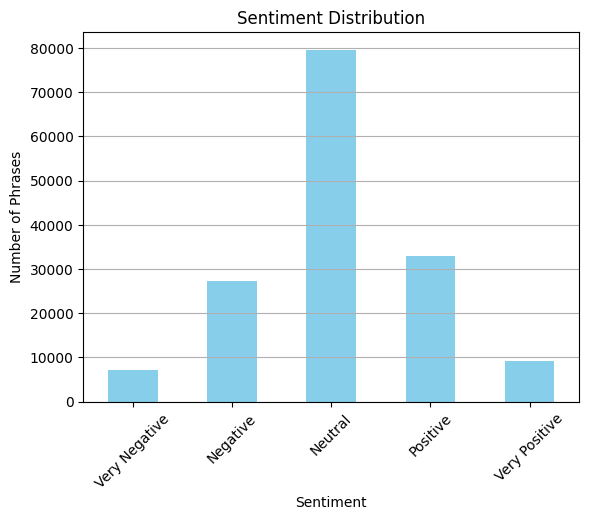

In [5]:
train_df['Sentiment'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Phrases')
plt.xticks(ticks=[0, 1, 2, 3, 4], labels=['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive'], rotation=45)
plt.grid(axis='y')
plt.show()

სიტყვის სენტიმენტს არ ცვლის პუნქტუაცია, stop wordები და რიცხვები როგორც წესი. აქედან გამომიდინარე შეგვიძლია, რომ ფრაზების სიგრძე შემცირდება, რაც სწავლისთვის უკეთესი იქნება. ასევე, შეიძლება ერთიდაიგივე სიტყვები ცოტა სხვადასხვა ფორმით შემხვდეს და არ რომ სხვადასხვად აღვიქვა, რის გამოც lemmatizerს გავუკეთებ.

In [6]:
stop_words = set(stopwords.words('english'))
punctuation = set(string.punctuation)
lemmatizer = nltk.stem.WordNetLemmatizer()

def clean_text(text):
    tokens = word_tokenize(text.lower())

    cleaned = []
    for token in tokens:
        if token in stop_words or token in punctuation:
            continue
        if token.isnumeric():
            continue
        if re.match(r'^[a-zA-Z]+$', token):
            lemmatized = lemmatizer.lemmatize(token)
            cleaned.append(lemmatized)

    return ' '.join(cleaned)

train_df['Cleaned_Phrase'] = train_df['Phrase'].apply(clean_text)

print(train_df[['Phrase', 'Cleaned_Phrase']].sample(5))

                                                   Phrase  \
80556   What is sorely missing , however , is the edge...   
12273   one of the most plain white toast comic book f...   
140006                 it almost wins you over in the end   
7242    puzzles me is the lack of emphasis on music in...   
99844   The connected stories of Breitbart and Hanusse...   

                                           Cleaned_Phrase  
80556   sorely missing however edge wild lunatic inven...  
12273               one plain white toast comic book film  
140006                                     almost win end  
7242    puzzle lack emphasis music britney spear first...  
99844   connected story breitbart hanussen actually fa...  


ცარიელი სტრინგები წავშალოთ.

In [7]:
train_df = train_df[train_df['Cleaned_Phrase'].str.strip() != '']

ბევრად უფრო შემცირდა ფრაზის სიგრძები რაც ჰისტოგრამაზე კარგად ჩანს.

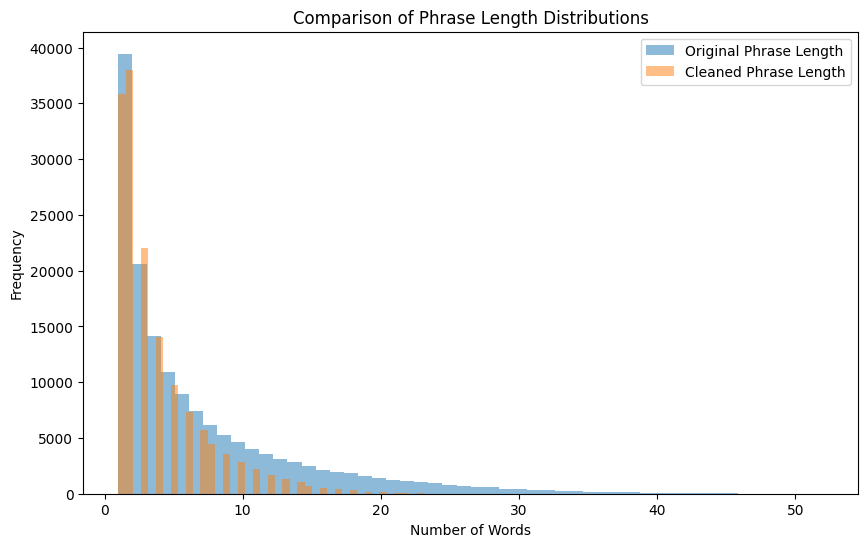

In [8]:
train_df['Phrase_Length'] = train_df['Phrase'].apply(lambda x: len(x.split()))
train_df['Cleaned_Phrase_Length'] = train_df['Cleaned_Phrase'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 6))
plt.hist(train_df['Phrase_Length'], bins=50, alpha=0.5, label='Original Phrase Length')
plt.hist(train_df['Cleaned_Phrase_Length'], bins=50, alpha=0.5, label='Cleaned Phrase Length')
plt.title('Comparison of Phrase Length Distributions')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.legend()
plt.show()

ახლა რა სვეტებიც დავამატე მაგეებს წავშლი, ასევე phrase და სიგრძეებს.

In [9]:
train_df = train_df.drop(['Phrase', 'Phrase_Length', 'Cleaned_Phrase_Length'], axis=1)

### შედეგი

In [10]:
train_df = train_df.reset_index(drop=True)

train_df.head()

,Sentiment,Cleaned_Phrase
0,1,series escapade demonstrating adage good goose...
1,2,series escapade demonstrating adage good goose
2,2,series
3,2,series
4,2,escapade demonstrating adage good goose


## ლექსიკონი

სიტყვების embeddingები რომ ვქნა, მაგისთვის მჭირდება რომ ლექსიკონი შევქმნა. თავდაპირველად დავითავლე სიტყვების სიხშირეები და ასევე გავითვალისწინე უცნობი სიტყვები და ამის შემდეგ ლექსიკონის გამოყენებით თითოეულ სიტყვას შევუსაბამე მისი შესაბამისი სიტყვების ინდექსების ლისტი.

In [11]:
def build_vocab(phrases, min_freq=1, max_vocab_size=None):
    counter = Counter(word for phrase in phrases for word in phrase.split())

    vocab = {"<pad>": 0, "<unk>": 1}

    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)
            if max_vocab_size and len(vocab) >= max_vocab_size:
                break

    return vocab

In [12]:
class PhraseDataset(Dataset):
    def __init__(self, phrases, labels, word2idx, max_length=None):
        self.phrases = phrases
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.word2idx = word2idx
        self.max_length = max_length

    def __len__(self):
        return len(self.phrases)

    def __getitem__(self, idx):
        phrase = self.phrases[idx]
        tokens = [self.word2idx.get(word, self.word2idx.get("<unk>")) for word in phrase.split()]

        encoded_phrase = torch.tensor(tokens, dtype=torch.long)

        return encoded_phrase, self.labels[idx]

ამასაც იმისთვის ვიყენებ, რომ LSTMისთვის მოვამზადო მონაცემები და ყველა ინფუთს ერთიდაიგივე სიგრძე ჰქონდეს. ასევე, ვსორტავ სიგრძის მიხედვით ფრაზებს, რათა LSTMმა უკეთესი პერფორმასი დადოს, რადგან აღარ დასჭირდება ნაკლებად გამოიყენებს არასაჭირო paddingებს თავიდან.

In [13]:
def collate_fn(batch):
    batch.sort(key=lambda x: len(x[0]), reverse=True)
    phrases, labels = zip(*batch)
    lengths = torch.tensor([len(phrase) for phrase in phrases])
    padded_phrases = pad_sequence(phrases, batch_first=True, padding_value=0)
    labels = torch.stack(labels)

    return padded_phrases, lengths, labels

## მოდელი – Bi-LSTM

მოდელი შედგება სამი ძირითადი ლეიერისგან: **Embedding**, **Bi-LSTM** და **Fully Connected Linear**.
*   Embedding ლეირი უზრუნველყოფს, რომ სიტყვა ვექტორად წარმოვადგინოთ და თავისით პოულობს მოდელი ამ ვექტორებს.
*   Bi-LSTMს ლეიერს ვიყენებ, რადგან ფრაზა ორივე მხრიდან გაიაზროს.
*   Dropoutს ლეიერს ვაკეთებ, რადგან ზოგადი მოდელი მინდა რომ იყოს და overfittingის მიმცირებს.
*   Fully Connected Linear ლეიერს იმისთვის ვიყენებ, რომ forward და backword LSTMის შედეგები შევაჯამო.
*   Softmaxს იმაში ვიყენებ, რომ multi-class კლასიფიკაცია გავაკეთო


In [14]:
class PhraseClassifier(nn.Module):
    def __init__(self, vocab_sz, embedding_dim, hidden_sz, num_lstm_layers, dropout_prob, num_classes):
        super(PhraseClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_sz, embedding_dim)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_sz,
            num_layers=num_lstm_layers,
            dropout=dropout_prob if num_lstm_layers > 1 else 0,
            bidirectional=True,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout_prob)
        self.fc = nn.Linear(hidden_sz * 2, num_classes)

    def forward(self, text, lengths):
        embedded = self.embedding(text)

        packed_embedded = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=True
        )
        packed_output, (hidden, _) = self.lstm(packed_embedded)

        hidden_concat = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        hidden_dropout = self.dropout(hidden_concat)

        return self.fc(hidden_dropout)

## ტრენინგი

### ჰიპერპარამეტრები

In [15]:
EMBEDDING_DIM = 100
HIDDEN_SIZE = 128
NUM_LSTM_LAYERS = 2
DROPOUT = 0.2
BATCH_SIZE = 64
LEARNING_RATE = 0.001
NUM_EPOCHS = 6
NUM_CLASSES = 5

### ტრენინგის ფუნქცია

In [16]:
def train_model(model, train_loader, valid_loader, criterion, optimizer, device, num_epochs=5):
    best_valid_loss = float('inf')

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        correct_predictions = 0
        total_predictions = 0

        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')

        for batch in progress_bar:
            phrases, lengths, labels = batch
            phrases, labels = phrases.to(device), labels.to(device)

            optimizer.zero_grad()

            predictions = model(phrases, lengths)

            loss = criterion(predictions, labels)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            _, predicted_classes = predictions.max(1)
            correct_predictions += (predicted_classes == labels).sum().item()
            total_predictions += labels.size(0)

            progress_bar.set_postfix({
                'loss': loss.item(),
                'accuracy': correct_predictions / total_predictions
            })

        train_loss = epoch_loss / len(train_loader)
        train_accuracy = correct_predictions / total_predictions

        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'\tTrain Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}')

        if valid_loader:
            valid_loss, valid_accuracy = evaluate_model(model, valid_loader, criterion, device)
            print(f'\tValid Loss: {valid_loss:.4f}, Valid Accuracy: {valid_accuracy:.4f}')

            if valid_loss < best_valid_loss:
                best_valid_loss = valid_loss
                torch.save(model.state_dict(), 'best_sentiment_model.pt')
                print(f'\tBest validation loss: {best_valid_loss:.4f}')

        print()

    return model

### ევალუაციის ფუნქცია

In [17]:
def evaluate_model(model, data_loader, criterion, device):
    model.eval()
    epoch_loss = 0
    correct_predictions = 0
    total_predictions = 0

    with torch.no_grad():
        for batch in data_loader:
            phrases, lengths, labels = batch
            phrases, labels = phrases.to(device), labels.to(device)

            predictions = model(phrases, lengths)

            loss = criterion(predictions, labels)

            epoch_loss += loss.item()

            _, predicted_classes = predictions.max(1)
            correct_predictions += (predicted_classes == labels).sum().item()
            total_predictions += labels.size(0)

    return epoch_loss / len(data_loader), correct_predictions / total_predictions

### თვით ტრენინგი

In [18]:
X_train, X_val, y_train, y_val = train_test_split(
    train_df["Cleaned_Phrase"].tolist(),
    train_df["Sentiment"].tolist(),
    test_size=0.1,
    random_state=42,
    stratify=train_df["Sentiment"].tolist()
)

vocab = build_vocab(X_train, min_freq=2)

train_dataset = PhraseDataset(X_train, y_train, vocab)
valid_dataset = PhraseDataset(X_val, y_val, vocab)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

model = PhraseClassifier(
    vocab_sz=len(vocab),
    embedding_dim=EMBEDDING_DIM,
    hidden_sz=HIDDEN_SIZE,
    num_lstm_layers=NUM_LSTM_LAYERS,
    dropout_prob=DROPOUT,
    num_classes=NUM_CLASSES
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=0.0001)

model = train_model(
    model=model,
    train_loader=train_loader,
    valid_loader=valid_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=NUM_EPOCHS
)

Epoch 1/6: 100%|██████████| 2142/2142 [00:24<00:00, 86.41it/s, loss=0.839, accuracy=0.561]


Epoch 1/6:
	Train Loss: 1.0954, Train Accuracy: 0.5611
	Valid Loss: 0.9681, Valid Accuracy: 0.6081
	Best validation loss: 0.9681



Epoch 2/6: 100%|██████████| 2142/2142 [00:24<00:00, 85.84it/s, loss=1.1, accuracy=0.63]


Epoch 2/6:
	Train Loss: 0.9099, Train Accuracy: 0.6299
	Valid Loss: 0.9080, Valid Accuracy: 0.6291
	Best validation loss: 0.9080



Epoch 3/6: 100%|██████████| 2142/2142 [00:24<00:00, 88.21it/s, loss=0.945, accuracy=0.647]


...

Epoch 4/6:
	Train Loss: 0.8342, Train Accuracy: 0.6575
	Valid Loss: 0.8785, Valid Accuracy: 0.6425
	Best validation loss: 0.8785



Epoch 5/6: 100%|██████████| 2142/2142 [00:23<00:00, 90.99it/s, loss=0.599, accuracy=0.665]


Epoch 5/6:
	Train Loss: 0.8125, Train Accuracy: 0.6655
	Valid Loss: 0.8700, Valid Accuracy: 0.6438
	Best validation loss: 0.8700



Epoch 6/6: 100%|██████████| 2142/2142 [00:23<00:00, 91.29it/s, loss=0.646, accuracy=0.672]


Epoch 6/6:
	Train Loss: 0.7952, Train Accuracy: 0.6724
	Valid Loss: 0.8744, Valid Accuracy: 0.6439



## მიღებული შედეგის გატესტვა

მეთოდი რომელიც გვეტყვის ფრაზის სენტიმენტს.

In [19]:
def predict_sentiment(model, vocab, device, phrases):
    model.eval()
    results = []

    for phrase in phrases:
        if not isinstance(phrase, str):
            phrase = ""

        phrase = clean_text(phrase)

        tokens = [vocab.get(word, vocab.get("<unk>")) for word in phrase.split()]
        if len(tokens) == 0:
            tokens = [vocab.get("<pad>")]

        tensor = torch.tensor([tokens], dtype=torch.long).to(device)
        lengths = torch.tensor([len(tokens)])

        with torch.no_grad():
            prediction = model(tensor, lengths)
            _, predicted_class = prediction.max(1)
            sentiment_index = predicted_class.item()

        results.append(sentiment_index)
    return results

### ხელით რაღაცა ინფუთებზე

ამ სამ ფრაზაზე ნორმალური შედეგი დააბრუნა.

In [20]:
index_to_sentiment = {
    0: "Very Negative",
    1: "Negative",
    2: "Neutral",
    3: "Positive",
    4: "Very Positive"
}

test_phrases = [
    "this movie was amazing and heartfelt",
    "terrible acting and poor direction",
    "okay"
]

results = predict_sentiment(
    model,
    vocab,
    device,
    test_phrases
)

for i in range(len(results)):
    print(f"Phrase: '{test_phrases[i]}'")
    print(f"Sentiment: {index_to_sentiment[results[i]]}\n")

Phrase: 'this movie was amazing and heartfelt'
Sentiment: Very Positive

Phrase: 'terrible acting and poor direction'
Sentiment: Very Negative

Phrase: 'okay'
Sentiment: Neutral



### kaggleის სატესტო მონაცემებზე

In [21]:
test_phrases = test_df['Phrase'].fillna("").tolist()

test_predictions = predict_sentiment(model, vocab, device, test_phrases)

test_df['Sentiment'] = test_predictions

output_df = test_df[['PhraseId', 'Sentiment']]

output_df.to_csv('./submission.csv', index=False)

kaggleზე submissionის ქულა **0.61968** არის.

## მოდელის შენახვა

In [22]:
torch.save(model.state_dict(), 'model.pt')